In [1]:
import pandas as pd
import numpy as np
import os, glob
import re
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [2]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 5

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.18
plt.rcParams['figure.subplot.left'] = 0.1
plt.rcParams['figure.subplot.right'] = 0.97
plt.rcParams['figure.subplot.top'] = 0.98
plt.rcParams['figure.subplot.wspace'] = 0.03
plt.rcParams['figure.subplot.hspace'] = 0.03



In [72]:

model_dct = {
    'ompa': {'modal': ['mpa', 'omat24'], 'label': 'ompa'},
    'mace': {'modal': ['mpa', 'omat'], 'label': 'MACE'},
    'orb': {'modal': ['mpa', 'omat'], 'label': 'ORB'},
    'esen': {'modal': ['oam', 'omat'], 'label': 'eSEN'},
    'dpa': {'modal': ['mp', 'omat'], 'label': 'DPA'},
    'uma': {'modal': ['omat'], 'label': 'UMA'},
    'omni': {'modal': ['mpa', 'omat24', 'matpes_pbe'], 'label': 'omni'},
    'grace': {'modal': ['oam', 'omat'], 'label': 'GRACE'},
    'nequip': {'modal': ['oam'], 'label': 'NequIP'},
        }
solutes = ['Co', 'Cr', 'Cu', 'Mn', 'Mo', 'Nb', 'Ni', 'Ti', 'V']

run_params = {'date': '250916', 'fmax': ['1e-2', '0.5e-3'], 'cell': ['ucf', 'frech']}
head = f'/Users/dnjf/__module__/febench/{run_params["date"]}'
label_list = []
for fmax in run_params['fmax']:
    for cell in run_params['cell']:
        label_list.append(f'fmax_{fmax}_{cell}')
models = mlip_list = [
    "ompa-mpa", "ompa-omat24", "mace-mpa","mace-omat",
    "orb-mpa","orb-omat","esen-oam","esen-omat",
    "dpa-mp","dpa-omat", "uma-omat",
    "omni-mpa","omni-omat24","omni-matpes_pbe",
    "grace-oam","grace-omat", "nequip-oam"
]
print(label_list)
prefix = 'fmax_1e-2_frech'

models = mlip_list = [
    "esen-oam","esen-omat",
    "uma-omat",
    "omni-mpa","omni-omat24","omni-matpes_pbe",
    "grace-oam","grace-omat", "nequip-oam"
]
models = mlip_list = [
    "ompa-mpa", "ompa-omat24", "mace-mpa","mace-omat",
    "orb-mpa","orb-omat","esen-oam","esen-omat",
    "dpa-mp","dpa-omat", "uma-omat",
    "omni-mpa","omni-omat24","omni-matpes_pbe",
    "grace-oam","grace-omat", "nequip-oam"
]

['fmax_1e-2_ucf', 'fmax_1e-2_frech', 'fmax_0.5e-3_ucf', 'fmax_0.5e-3_frech']


In [66]:

color_dict= {
    'ompa-omat24': '#02baae',
    'ompa-mpa': '#72b8b3',
    'omni-omat24': '#0073ff',
    'omni-mpa': '#8cbbf5',
    'omni-matpes_pbe': '#0047b3',
    'orb-omat': '#d48f3f',
    'orb-mpa': '#d9ba98',
    'esen-omat':'#e8d803',
    'esen-oam': '#f5ea74',
    'dpa-mp': '#d19adf',
    'dpa-omat': '#e829f6',
    'uma-omat': '#ff0000',
    'uma-omc': '#ff7f7f',
    'mace-omat': '#00b300',
    'mace-mpa': '#66ff66',
    'grace-omat': '#8b4513',
    'grace-oam': '#deb887',
    'nequip-oam': '#a52a2a',
}

solute_color_dict = {
    'Co': '#95bcff',
    'Cr': '#efa366',
    'Cu': '#03bc25',
    'Mn': '#ffa9ec',
    'Mo': '#b1ffba',
    'Nb': '#adadad',
    'Ni': '#e2e2e2',
    'Ti': '#00d4df',
    'V': '#fee900',
}

In [73]:
carbon_mae = pd.read_csv('carbon_mae.csv',index_col=0)
tm_mae = pd.read_csv('tm_mae.csv',index_col=0)
tot_mae = pd.read_csv('tot/tot_mae.csv',index_col=0)
carbon_mae.drop(index=['dft'], inplace=True)
tm_mae.drop(index=['dft'], inplace=True)
tot_mae.drop(index=['dft'], inplace=True)
carbon_error = pd.read_csv(f'{prefix}/carbon_error_{prefix}.csv')
tm_error = pd.read_csv(f'{prefix}/tm_error_{prefix}.csv')
tot_error = pd.read_csv(f'tot/tot_error_{prefix}.csv')

carbon_df = pd.read_csv(f'{prefix}/carbon_aug_{prefix}.csv')
tm_df = pd.read_csv(f'{prefix}/tm_aug_{prefix}.csv')
tot_df = pd.read_csv(f'tot/tot_aug_{prefix}.csv')

carbon_sns = pd.DataFrame(columns=['mlip', 'delta'])
idx = 0
for i in range(len(carbon_error)):
    for mlip in mlip_list:
        carbon_sns.loc[idx] = [mlip, carbon_error[mlip][i]]
        idx += 1
tm_sns = pd.DataFrame(columns=['mlip', 'delta'])
idx = 0
for i in range(len(tm_error)):
    for mlip in mlip_list:
        tm_sns.loc[idx] = [mlip, tm_error[mlip][i]]
        idx += 1
tot_sns = pd.DataFrame(columns=['mlip', 'delta'])
idx = 0
for i in range(len(tot_error)):
    for mlip in mlip_list:
        tot_sns.loc[idx] = [mlip, tot_error[mlip][i]]
        idx += 1

carbon_sns.to_csv('carbon_sns.csv', index=False)
tm_sns.to_csv('tm_sns.csv', index=False)
tot_sns.to_csv('tot_sns.csv', index=False)


/var/folders/2y/dn00045d5fg2lmwsv7hjx9240000gn/T/ipykernel_38566/3893476883.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


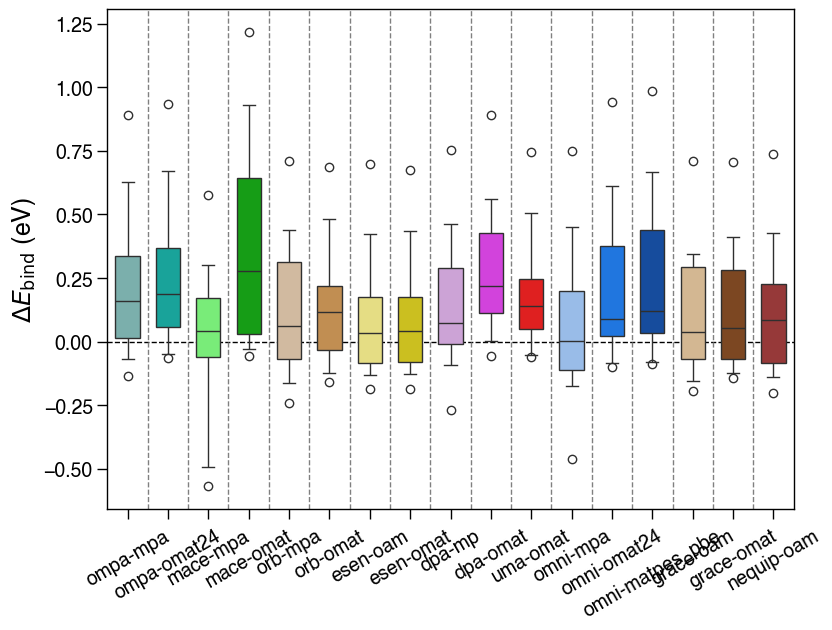

Box plot saved as box_h_carbon.png


/var/folders/2y/dn00045d5fg2lmwsv7hjx9240000gn/T/ipykernel_38566/3893476883.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


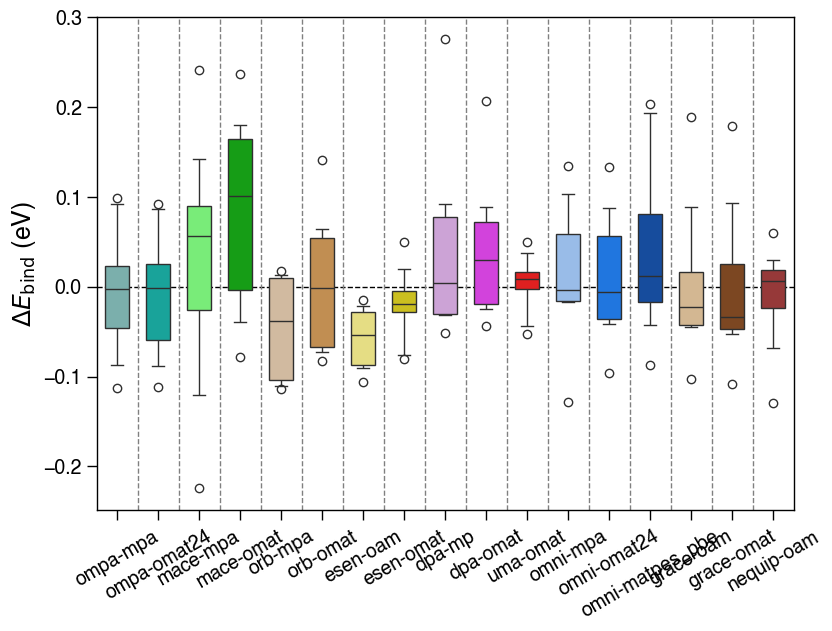

Box plot saved as box_h_tm.png


/var/folders/2y/dn00045d5fg2lmwsv7hjx9240000gn/T/ipykernel_38566/3893476883.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


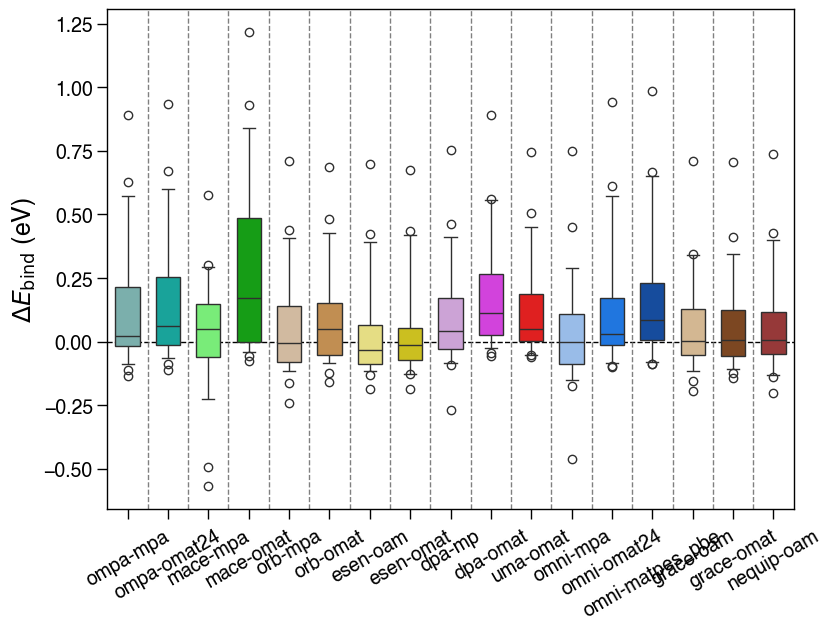

Box plot saved as box_h_tot.png


In [74]:
def plot_box(sns_df,filename):
    plt.figure(figsize=(8.5,6.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]
    sns.boxplot(
        data=sns_df,
        x="mlip",
        y="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.6
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
        
    plt.tick_params(axis="x", which="major", pad=5)
    plt.savefig(filename, transparent=True)
    # plt.close()
    plt.tight_layout()
    plt.show()
    print(f'Box plot saved as {filename}')


plot_box(carbon_sns, 'box_h_carbon.png')
plot_box(tm_sns, 'box_h_tm.png')
plot_box(tot_sns, 'box_h_tot.png')

/var/folders/2y/dn00045d5fg2lmwsv7hjx9240000gn/T/ipykernel_38566/2853715026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


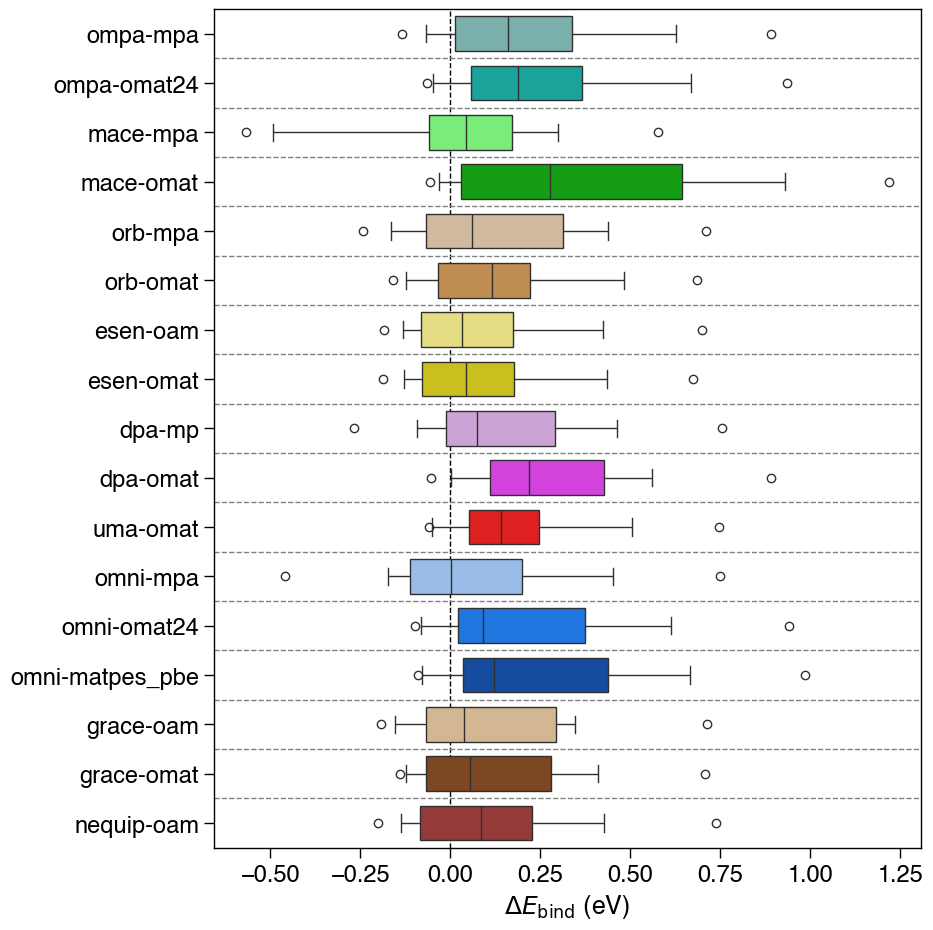

Box plot saved as box2_carbon.png


/var/folders/2y/dn00045d5fg2lmwsv7hjx9240000gn/T/ipykernel_38566/2853715026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


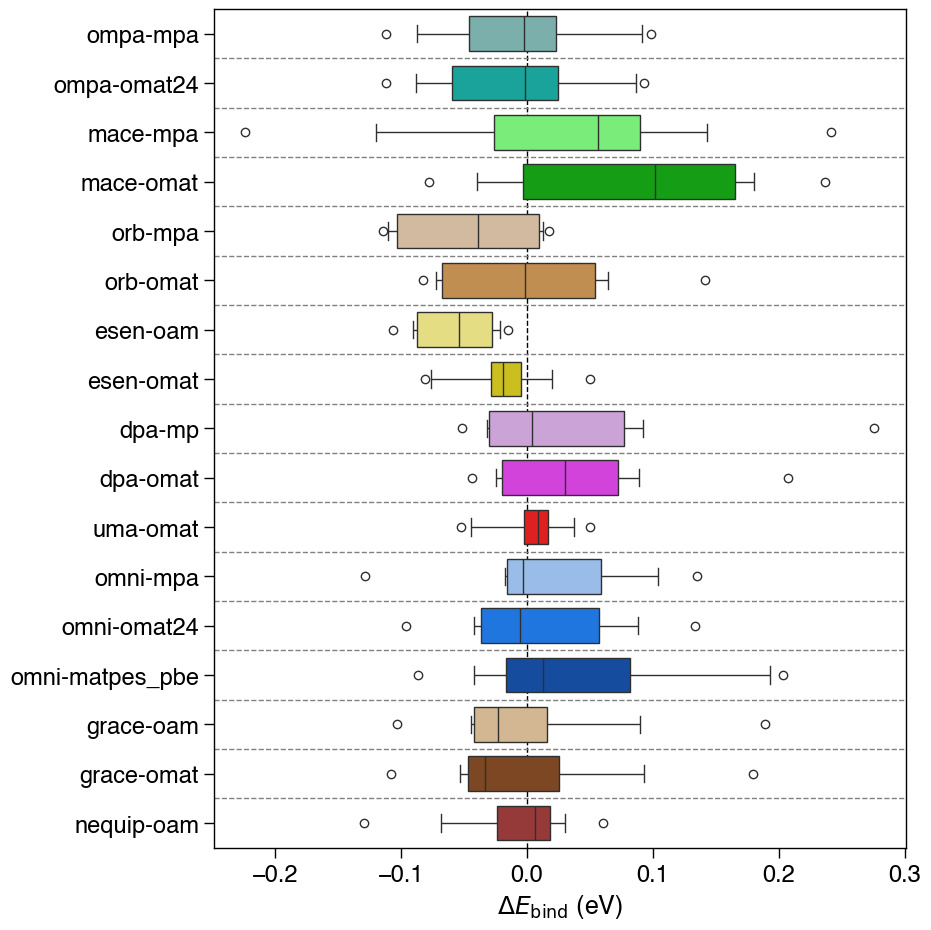

Box plot saved as box2_tm.png


/var/folders/2y/dn00045d5fg2lmwsv7hjx9240000gn/T/ipykernel_38566/2853715026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


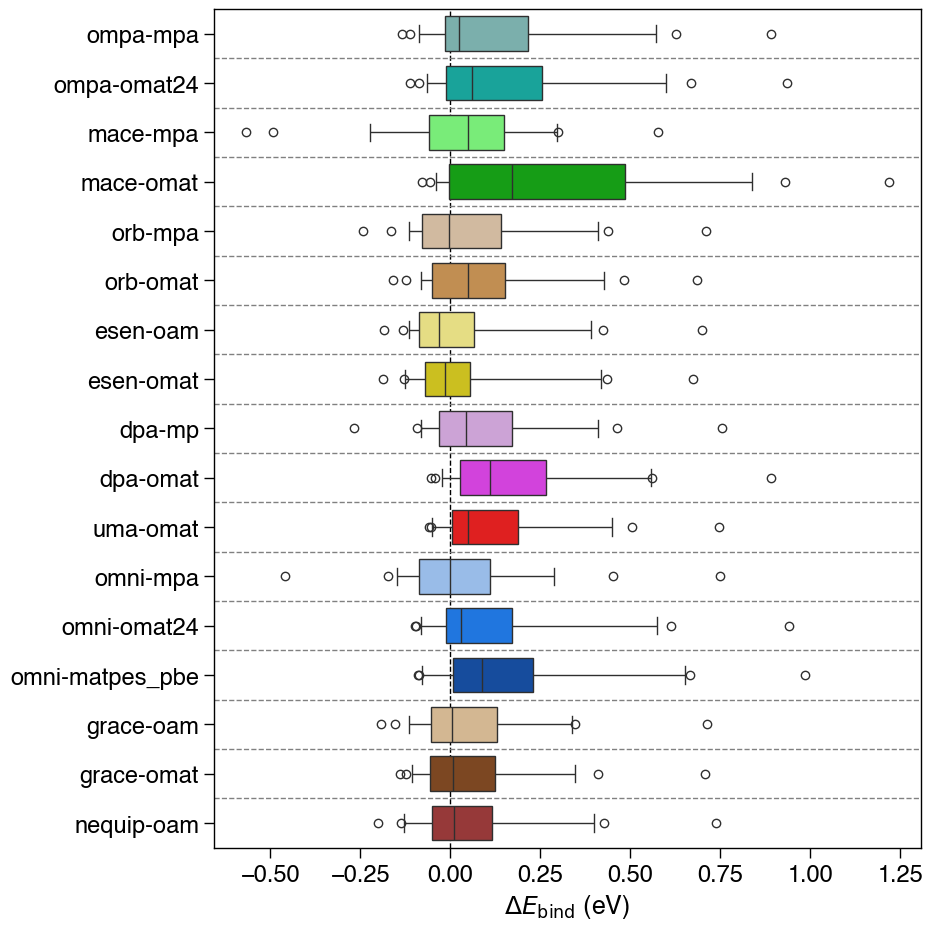

Box plot saved as box2_tot.png


In [60]:
def plot_box(sns_df,filename):
    plt.figure(figsize=(9.5,9.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]
    sns.boxplot(
        data=sns_df,
        y="mlip",
        x="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.7
    )
    plt.yticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='right', rotation=0, fontsize=17, fontweight='bold')
    plt.axvline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vlines:
        plt.axhline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.xlabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.ylabel("")
        
    plt.tick_params(axis="x", which="major", pad=5, labelsize=17)
    plt.savefig(filename, bbox_inches='tight', transparent=True)
    # plt.close()
    plt.tight_layout()
    plt.show()
    print(f'Box plot saved as {filename}')
    

plot_box(carbon_sns, 'box2_carbon.png')
plot_box(tm_sns, 'box2_tm.png')
plot_box(tot_sns, 'box2_tot.png')

In [52]:
def plot_violin(sns_df, filename):
    plt.figure(figsize=(15,5.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]

    sns.violinplot(
        data=sns_df,
        x="mlip",
        y="delta",          
        inner="quartile",
        cut=0,
        palette=color_dict
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
    
    # sns.despine()
    
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tight_layout()
    plt.savefig(filename, transparent=True)
    plt.show()

    print(f'Violin plot saved as {filename}')
